# Generate samples

In [1]:

import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

add_feature_bin = False
eid = "E116"
fold = 0


targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

binsizes = [500]

#
# Setup end.
#
seed=123
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.



EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Generate samples with the scores

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/4244861593.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/4244861593.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


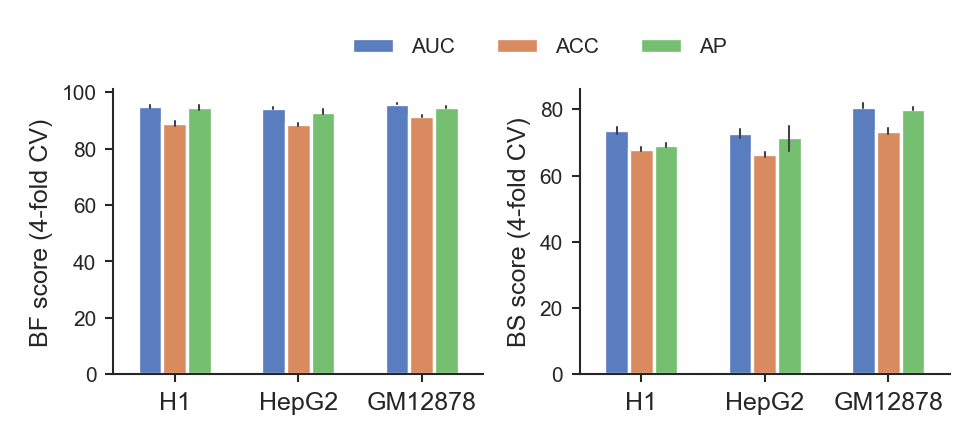

In [12]:
indicators = pd.read_csv('extra/datasets/results/indicators.csv')

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 3/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')

sns.barplot(data=indicators[indicators['target']=='bf_label'],x='eid',y='value',hue='indicator',ax=ax[0],order=order,
            width=0.6,err_kws={'linewidth': 0.5},palette="muted")
# [(0/255, 153/255,72/255), (247/255, 185/255,129/255), (14/255, 111/255, 182/255)]
sns.barplot(data=indicators[indicators['target']=='bs_label'],x='eid',y='value',hue='indicator',ax=ax[1],order=order,
            width=0.6,err_kws={'linewidth': 0.5},palette="muted")

# plt.legend(loc='upper left', bbox_to_anchor=(1, 1),title='Indicators',fontsize=8)  # Moves the legend outside the 
# plt.legend().remove()
# Show the plot
ax[0].set_ylabel("BF score (4-fold CV)",fontsize=6)
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_ylabel("BS score (4-fold CV)",fontsize=6)
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xlabel('')

ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# ax[0].set_ylim(ymin=50,ymax=100)
# ax[1].set_ylim(ymin=40,ymax=85)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.77, 1.15), fontsize=5,ncol=3,edgecolor='none')
plt.savefig('extra/datasets/figures/Figure2C.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/1628033689.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=45)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


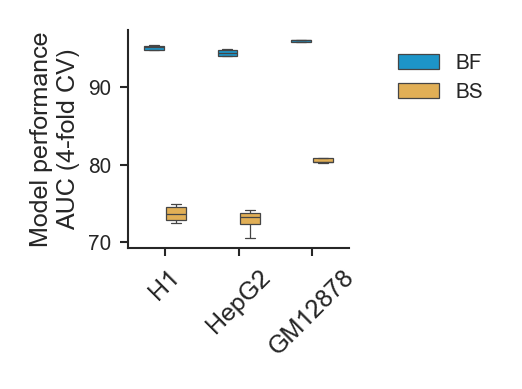

In [13]:
indicators = pd.read_csv('extra/datasets/results/indicators.csv')

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(3/2.54, 3/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')

ax = sns.boxplot(data=indicators[indicators['indicator']=='AUC'],x='eid',y='value',hue='target',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax,order=order,
                 hue_order=hue_order,
                 gap=0.1,width=0.6,palette=[(0/255, 161/255, 229/255), (248/255, 182/255, 63/255)],)

# Show the plot
ax.set_ylabel("Model performance\nAUC (4-fold CV)",fontsize=6)
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=6,width=0.5)
ax.tick_params(axis='y', labelsize=5,width=0.5)
handles, labels = ax.get_legend_handles_labels()
labels = ["BF","BS"]
ax.legend().remove()

ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=45)


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=5,ncol=1,edgecolor='none')
plt.savefig('extra/datasets/figures/Figure2B.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/1254447393.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)


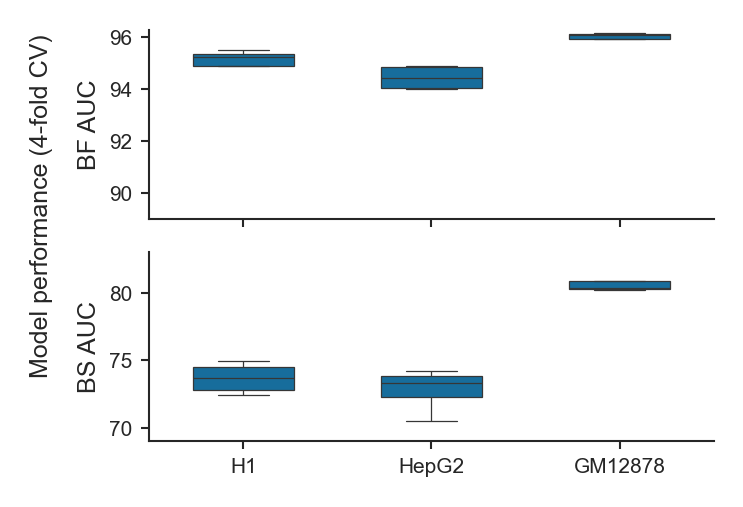

In [14]:
from matplotlib.ticker import FuncFormatter

indicators = pd.read_csv('extra/datasets/results/indicators.csv')

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')


# 自定义格式化函数
def format_func(value, tick_number):
    return f"{value:.0f}"



sns.boxplot(data=indicators[(indicators['indicator']=='AUC') & (indicators['target']=='bf_label')],x='eid',y='value',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax[0],order=order,
                #  hue_order=hue_order,
                 gap=0.1,width=0.6)

# Show the plot
ax[0].set_ylabel("BF AUC",fontsize=6)
ax[0].set_xlabel("")
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_ylim(ymin=89)
# handles, labels = ax.get_legend_handles_labels()
# labels = ["BF","BS"]
ax[0].legend().remove()

ax[0].set_xticklabels("")
ax[0].yaxis.set_major_formatter(FuncFormatter(format_func))



sns.boxplot(data=indicators[(indicators['indicator']=='AUC') & (indicators['target']=='bs_label')],x='eid',y='value',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax[1],order=order,
                #  hue_order=hue_order,
                 gap=0.1,width=0.6,)

# Show the plot
ax[1].set_ylabel("BS AUC",fontsize=6)
ax[1].set_xlabel("")
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_ylim(ymin=69)
# handles, labels = ax.get_legend_handles_labels()
# labels = ["BF","BS"]
ax[1].legend().remove()

ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)
ax[1].yaxis.set_major_formatter(FuncFormatter(format_func))

fig.supylabel('Model performance (4-fold CV)',fontsize=6,y=0.6)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=5,ncol=1,edgecolor='none')
plt.savefig('extra/datasets/figures/Figure2B.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

In [15]:
indicators

,eid,target,indicator,value,fold
0,E003,bs_label,AUC,74.377029,0
1,E003,bs_label,ACC,68.263989,0
2,E003,bs_label,AP,68.846091,0
3,E003,bf_label,AUC,94.109763,0
4,E003,bf_label,ACC,87.288379,0
...,...,...,...,...,...
67,E116,bs_label,ACC,73.100344,0
68,E116,bs_label,AP,80.281553,0
69,E116,bf_label,AUC,96.032144,0
70,E116,bf_label,ACC,91.951284,0


In [16]:
data = pd.read_csv(f'extra/datasets/results/{eid}_No_feature_bin_predictions.csv')
data

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold
0,ENSG00000054611,1,0.961865,1,1,0.980953,1,0
1,ENSG00000178445,1,0.674333,1,1,0.913891,1,0
2,ENSG00000184164,1,0.892111,1,1,0.967126,1,0
3,ENSG00000105550,0,0.296710,0,0,0.045679,0,0
4,ENSG00000102309,1,0.451373,0,1,0.872739,1,0
...,...,...,...,...,...,...,...,...
15636,ENSG00000223874,0,0.143599,0,0,0.008654,0,3
15637,ENSG00000128714,0,0.307697,0,0,0.115877,0,3
15638,ENSG00000114857,1,0.856059,1,1,0.976155,1,3
15639,ENSG00000168676,1,0.483998,0,0,0.410648,0,3


## Burst Frequency Test Data AURoc

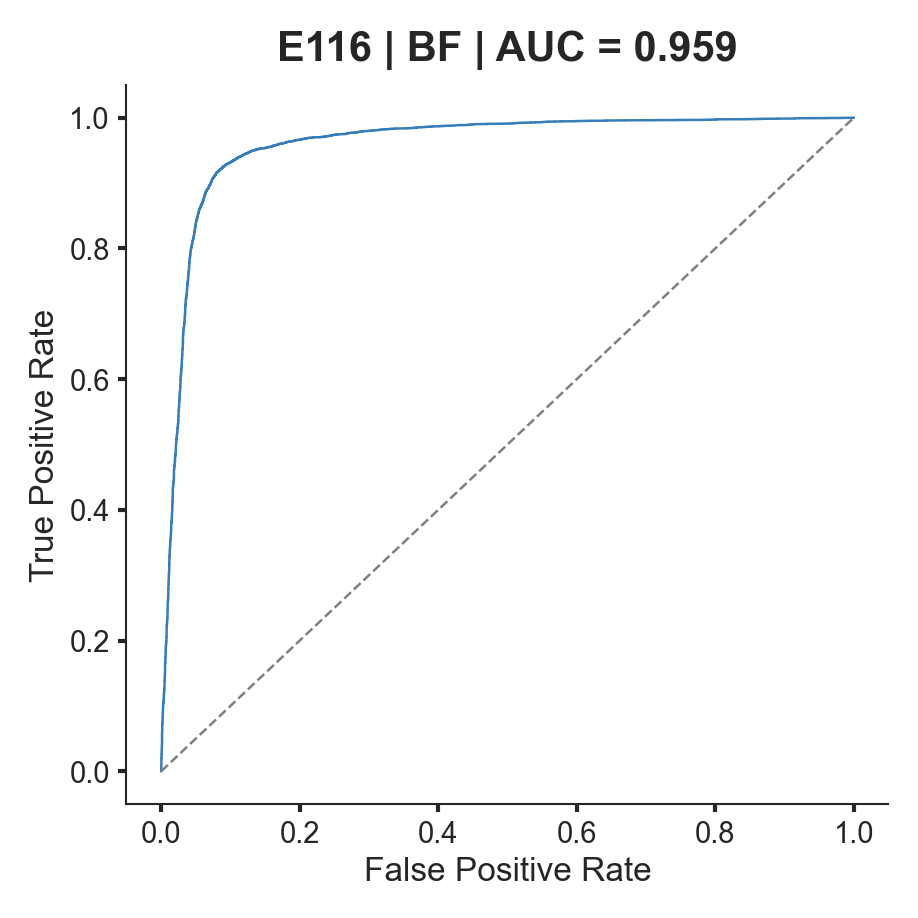

In [17]:
# 

fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BF | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()


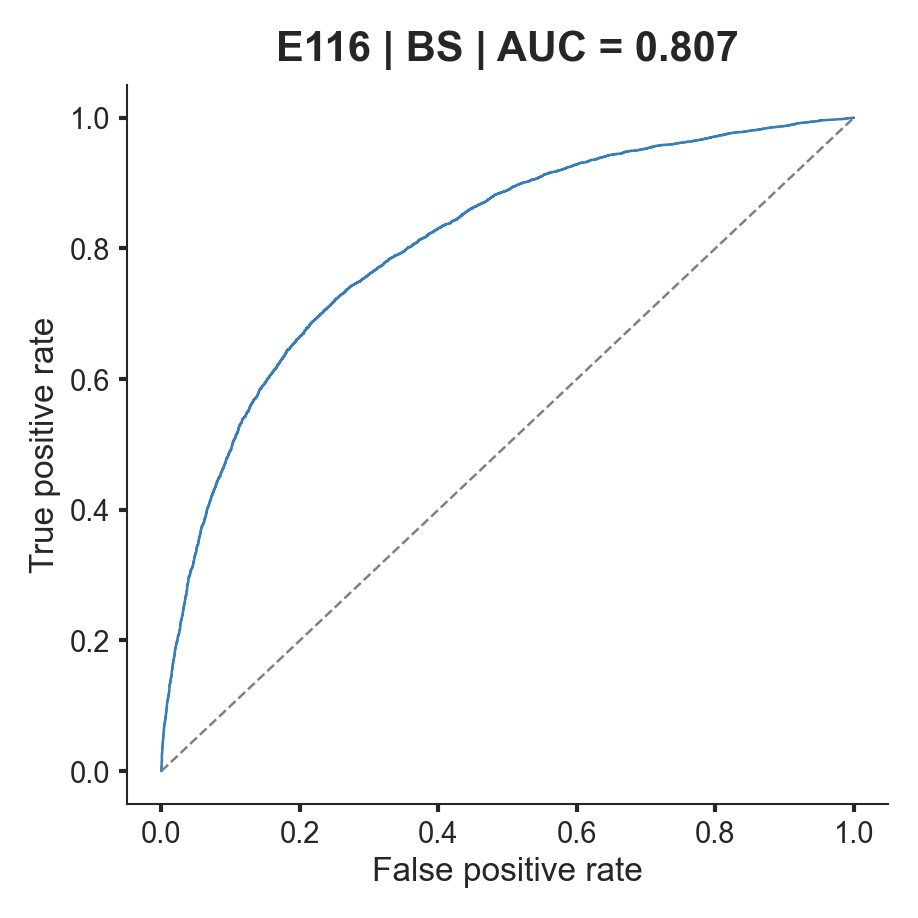

In [18]:
fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bs_label_label'],data['bs_label_pred'])

# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BS | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()

In [19]:
bs_fpr, bs_tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
bs_roc_auc = metrics.auc(fpr, tpr)
bs_f1_score = metrics.f1_score(data['bs_label_label'],data['bs_label_pred'])

bf_fpr, bf_tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
bf_roc_auc = metrics.auc(fpr, tpr)
bf_f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


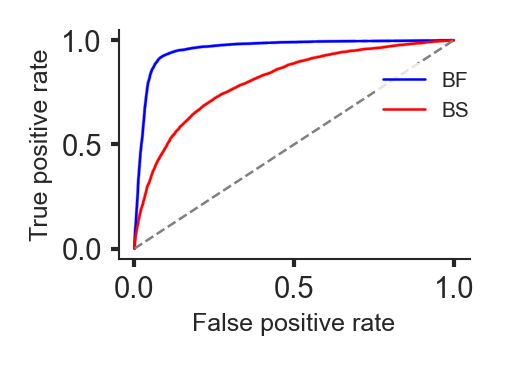

In [20]:
fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(4/2.54, 2.8/2.54))
# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
sns.lineplot(x=bf_fpr, y=bf_tpr, color='blue', lw=0.6,label='BF')
sns.lineplot(x=bs_fpr, y=bs_tpr, color='red', lw=0.6,label='BS')
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.legend(bbox_to_anchor=(0.7, 0.9),fontsize=5,edgecolor='none')
plt.xlabel('False positive rate',fontdict={'size':6})
plt.ylabel('True positive rate',fontdict={'size':6})
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})
plt.savefig('extra/datasets/figures/Figure1B.eps', format='eps', bbox_inches='tight')
# plt.title(f"{eid} | BS | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()

## Expression vs burst size / frequency 

In [4]:
data = pd.read_csv(f'extra/datasets/results/{eid}_predictions.csv')
    
data = pd.merge(data,meta[['gene_id','mean','mean_label']], how='inner',on='gene_id')

data['mean'] = np.log1p(data['mean'])

LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
def mark_label(x,y):
    if x == 0 and y==0:
        return  LABEL_BIN_MAP["Low bs and low bf"]
    if x == 1 and y ==0:
        return LABEL_BIN_MAP["High bs and low bf"]
    if x == 0 and y==1:
        return LABEL_BIN_MAP["Low bs and high bf"]
    if x == 1 and y == 1:
        return LABEL_BIN_MAP["High bs and high bf"]
data['pred_marks'] = data.apply(lambda row:mark_label(row['bs_label_pred'],row['bf_label_pred']), axis=1)
data['labels_marks'] = data.apply(lambda row:mark_label(row['bs_label_label'],row['bf_label_label']), axis=1)
data 

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,mean,mean_label,pred_marks,labels_marks
0,ENSG00000054611,1,0.888199,1,1,0.963504,1,0,0.430006,1,C4,C4
1,ENSG00000178445,1,0.638825,1,1,0.827021,1,0,0.271375,1,C4,C4
2,ENSG00000184164,1,0.738377,1,1,0.890130,1,0,1.758548,1,C4,C4
3,ENSG00000105550,0,0.176750,0,0,0.011561,0,0,0.000173,0,C1,C1
4,ENSG00000102309,1,0.426329,0,1,0.807096,1,0,0.660797,1,C3,C4
...,...,...,...,...,...,...,...,...,...,...,...,...
15636,ENSG00000223874,0,0.143599,0,0,0.008654,0,3,0.000000,0,C1,C1
15637,ENSG00000128714,0,0.307697,0,0,0.115877,0,3,0.000000,0,C1,C1
15638,ENSG00000114857,1,0.856059,1,1,0.976155,1,3,0.677585,1,C4,C4
15639,ENSG00000168676,1,0.483998,0,0,0.410648,0,3,0.000862,0,C1,C2


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2098798276.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['type'] = 'Pred groups'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2098798276.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['type'] = 'True groups'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2098798276.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

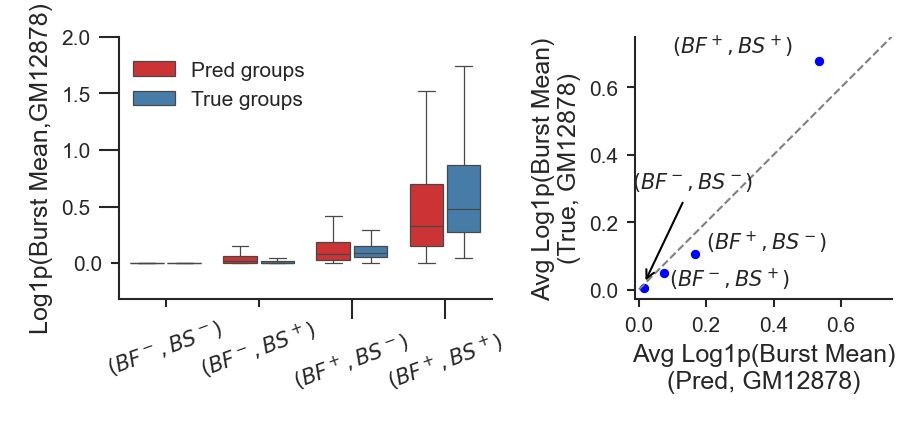

In [22]:
pred_marks = data[['pred_marks','mean']].groupby(by='pred_marks',as_index=False).mean()
pred_marks.columns = ['bins','mean']
labels_marks = data[['labels_marks','mean']].groupby(by='labels_marks',as_index=False).mean()
labels_marks.columns = ['bins','mean']

df_marks = pd.merge(pred_marks,labels_marks,on='bins')
r = stats.pearsonr(df_marks['mean_x'], df_marks['mean_y'])[0] * 100

fig, ax = plt.subplots(1, 2, constrained_layout=True,figsize=(8/2.54, 3.3/2.54))

sns.scatterplot(data=df_marks,x='mean_x',y='mean_y',s=6,color='blue',ax=ax[1])
ax[1].set_xlim(xmax=0.75)
ax[1].set_ylim(ymax=0.75)
ax[1].set_xlabel(f"Avg Log1p(Burst Mean)\n(Pred, {EIDS_TO_CELLTYPES[eid]})",fontsize=6)
ax[1].set_ylabel(f"Avg Log1p(Burst Mean)\n(True, {EIDS_TO_CELLTYPES[eid]})",fontsize=6)
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_aspect('equal')
ax[1].plot([0.001, 1], [0.001, 1], lw=0.5, color='gray', linestyle='--')

ax[1].annotate("$(BF^-,BS^-)$", xy=(0.01, 0.005), xytext=(-0.02,0.3), 
            arrowprops=dict(facecolor='black', edgecolor='black', 
                            linewidth=0.2, arrowstyle='->', 
                             shrinkA=0.1, lw=0.5, mutation_scale=5),fontsize=5)
ax[1].text(0.09,0.01,"$(BF^-,BS^+)$",fontdict={"size":5})
ax[1].text(0.2,0.12,"$(BF^+,BS^-)$",fontdict={"size":5})
ax[1].text(0.1,0.7,"$(BF^+,BS^+)$",fontdict={"size":5})


# 设置为 colorblind 调色板
sns.set_palette("colorblind")
sns.set_context("paper") 
order = pd.Index(["C1","C2","C3","C4"],name='marks')

df1 = data[['mean','pred_marks']]
df1.columns = ['mean','mark']
df1['type'] = 'Pred groups'

df2 = data[['mean','labels_marks']]
df2.columns = ['mean','mark']
df2['type'] = 'True groups'

df = pd.concat([df1,df2],axis=0)

sns.boxplot(data=df,y='mean',x='mark',hue='type',ax=ax[0],
            gap=0.1,width=0.8,fliersize=0,order=order,linewidth=0.3,
            palette="Set1")
ax[0].set_ylabel(f'Log1p(Burst Mean,{EIDS_TO_CELLTYPES[eid]})',fontsize=6)
ax[0].set_ylim(top=2)
ax[0].set_xticklabels(["$(BF^-,BS^-)$","$(BF^-,BS^+)$","$(BF^+,BS^-)$","$(BF^+,BS^+)$"],rotation=20,fontdict = {"size":5.5})  # ha参数用于设置水平对齐方式
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].legend().remove()
ax[0].legend(loc='upper right', bbox_to_anchor=(0.55, 0.98),fontsize=5,edgecolor='none')  # Moves the legend outside the 

ax[0].set_xlabel('')


plt.savefig('extra/datasets/figures/Figure2D.eps', format='eps', bbox_inches='tight')

plt.show()


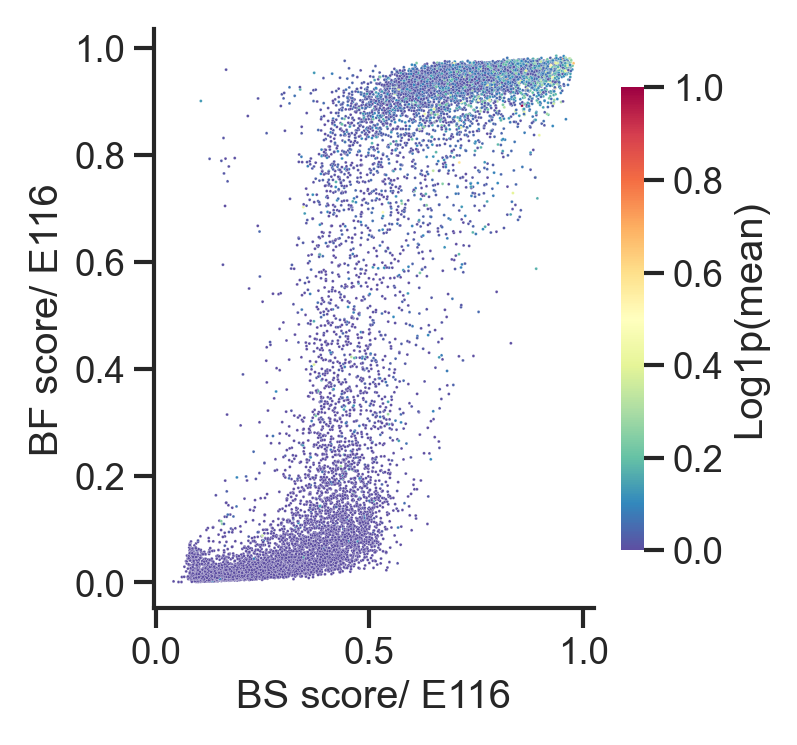

In [23]:
# Create the figure and axes
fig, ax = plt.subplots(figsize=(6/2.54, 6/2.54), dpi=300, facecolor='w', edgecolor='k')
fig.tight_layout(pad=1)

# Create the scatter plot
scatter = sns.scatterplot(
    x=data['bs_label_score'],
    y=data['bf_label_score'],
    hue=data['mean'],  # Use 'hue' to map colors
    palette='Spectral_r',  # Specify the colormap
    s=0.5,  # Set marker size to 0.1
    legend=False,  # Disable the legend
    ax=ax  # Specify the axes to plot on
)

# Add a colorbar
norm = plt.Normalize(data['mean'].min(), data['mean_label'].max())
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Log1p(mean)',shrink=0.8,location='right')  # Associate colorbar with the axes
cbar.outline.set_visible(False)
plt.ylabel(f"BF score/ {eid}")
plt.xlabel(f"BS score/ {eid}")

# Show the plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


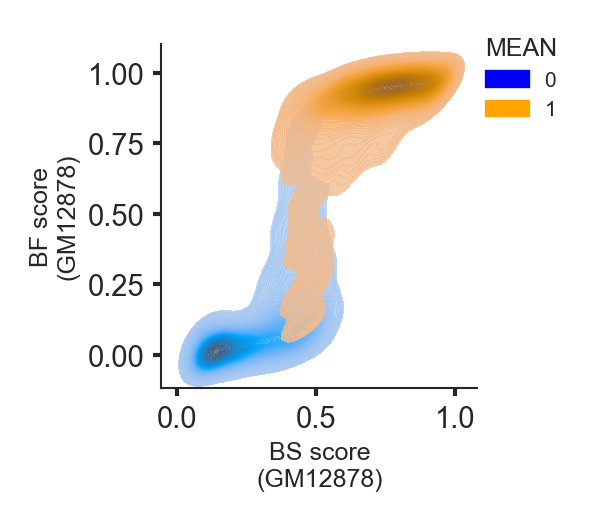

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建图形
fig, ax = plt.subplots(figsize=(4/2.54, 4/2.54), constrained_layout=True)

# 画密度图，分别绘制不同类别
ax = sns.kdeplot(
    data=data,
    x='bs_label_score',
    y='bf_label_score',
    levels=100,
    hue='mean_label',
    fill=True,
    alpha=0.8,
    ax=ax
)

# 设置坐标轴
ax.set_ylabel(f"BF score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
ax.set_xlabel(f"BS score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)

# 显示 legend
import matplotlib.patches as mpatches

# 手动创建 legend
legend_patches = [
    mpatches.Patch(color="blue", label=0),
    mpatches.Patch(color="orange", label=1)
]
ax.legend().remove()
# 添加 legend
fig.legend(handles=legend_patches, title="MEAN", loc="center left", bbox_to_anchor=(0.95, 0.9), title_fontsize=6,fontsize=5, frameon=False)

# 保存和显示
plt.savefig('extra/datasets/figures/Figure2C.eps', format='eps', bbox_inches='tight')
plt.show()

##  cell type specific

In [54]:
# import torch 
# from src.utils.constants import DEVICE

# eids = ['E003','E118','E116']
# with open('extra/datasets/benchmark/cell_type_specific.csv','w') as w:
#     line = ['bs_auc','bf_auc','fold','eid']
#     w.write('\t'.join(line) + '\n')
#     for fold in [0,1,2,3]:
#         for eid in eids:
#             checkpoints = f'checkpoints/{eid}.{fold}.model.pt'
#             ckpt = torch.load(checkpoints,map_location=DEVICE)
#             bs_auc = ckpt['bs_label_val_auc']
#             bf_auc = ckpt['bf_label_val_auc']
#             line = [str(bs_auc),str(bf_auc),str(fold), eid]
#             w.write('\t'.join(line) + '\n')
        
    
cell_type_agnostic = pd.read_csv(f'extra/datasets/results/valid.csv',sep='\t')
cell_type_agnostic['cell_type'] = 'Agnostic model'
cell_type_specific = pd.read_csv('extra/datasets/benchmark/cell_type_specific.csv',sep='\t')
cell_type_specific['cell_type'] = 'Specific model'
df_bs_bf = pd.concat([cell_type_specific,cell_type_agnostic], axis=0)
# bf_df = df[['bf_auc','fold','eid','cell_type']]
# bf_df.columns = ['auc','fold','eid','cell_type']
# bf_df['cell_type'] = 'bf_' + bf_df['cell_type'] 
# bs_df = df[['bs_auc','fold','eid','cell_type']]
# bs_df.columns = ['auc','fold','eid','cell_type']
# bs_df['cell_type'] = 'bs_' + bs_df['cell_type'] 

# df_melt = pd.concat([bs_df,bf_df], axis=0)
# df_melt



,auc,fold,eid,cell_type
0,98.342433,0,E116,mean_Agnostic model
1,98.584557,1,E116,mean_Agnostic model
2,98.748839,2,E116,mean_Agnostic model
3,98.807486,3,E116,mean_Agnostic model
4,95.214207,0,E118,mean_Agnostic model
5,96.062471,1,E118,mean_Agnostic model
6,96.336016,2,E118,mean_Agnostic model
7,97.301011,3,E118,mean_Agnostic model
8,95.703017,0,E003,mean_Agnostic model
9,95.481987,1,E003,mean_Agnostic model


### Cell type specific Model

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/1253724442.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/1253724442.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/1253724442.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


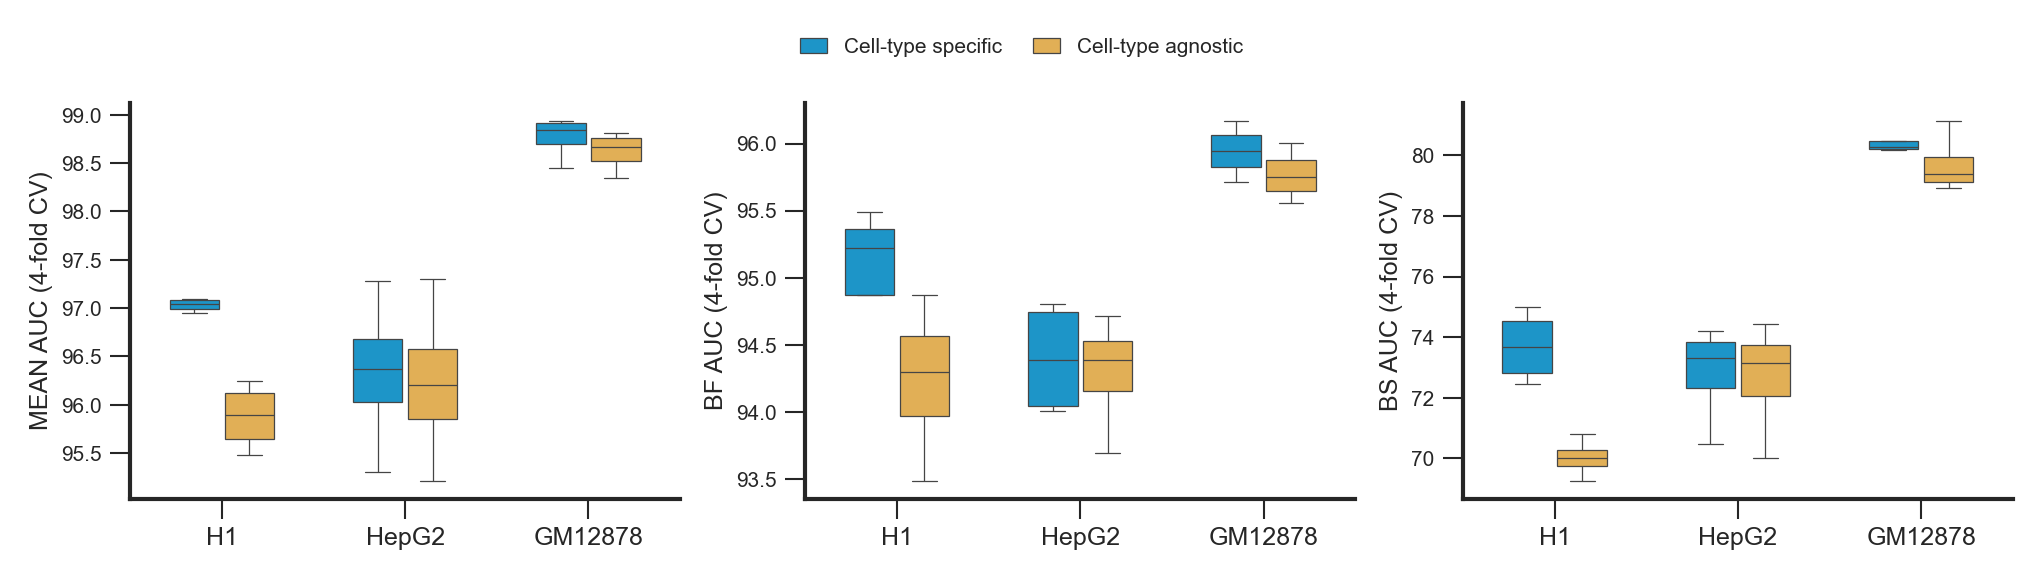

In [57]:

# 设置为 colorblind 调色板
fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(17/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
sns.set_palette("colorblind")
# sns.set_context("paper") 


sns.boxplot(data=df_bs_bf, x='eid',y='bf_auc',hue='cell_type',fliersize=0, linewidth=0.3,ax=ax[1],order=order,
            gap=0.1,width=0.6,palette=[(0/255, 161/255, 229/255), (248/255, 182/255, 63/255)])
sns.boxplot(data=df_bs_bf, x='eid',y='bs_auc',hue='cell_type',fliersize=0, linewidth=0.3,ax=ax[2],order=order,
            gap=0.1,width=0.6,palette=[(0/255, 161/255, 229/255), (248/255, 182/255, 63/255)],
            #              boxprops=dict( edgecolor=(128/255,128/255,128/255)),  
            # whiskerprops=dict(linewidth=0.5, color=(128/255,128/255,128/255))
            )
ax[1].set_ylabel("BF AUC (4-fold CV)",fontsize=6)
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[2].set_ylabel("BS AUC (4-fold CV)",fontsize=6)
ax[2].tick_params(axis='x', labelsize=6,width=0.5)
ax[2].tick_params(axis='y', labelsize=5,width=0.5)

ax[1].legend().remove()
ax[1].set_xlabel('')
ax[2].legend().remove()
ax[2].set_xlabel('')
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])

# ax[0].set_ylim(ymin=90,ymax=98)
# ax[1].set_ylim(ymin=60,ymax=85)

cell_type_agnostic = pd.read_csv('extra/datasets/results/valid_mean.csv',sep='\t')
cell_type_agnostic['cell_type'] = 'Agnostic model'
cell_type_specific = pd.read_csv('extra/datasets/benchmark/cell_type_specific_mean.csv',sep='\t')
cell_type_specific['cell_type'] = 'Specific model'
df = pd.concat([cell_type_specific,cell_type_agnostic], axis=0)
df = df[['mean_auc','fold','eid','cell_type']]
df.columns = ['auc','fold','eid','cell_type']
df['cell_type'] = 'mean_' + df['cell_type'] 

sns.boxplot(data=df, x='eid',y='auc',hue='cell_type',fliersize=0, linewidth=0.3,ax=ax[0],order=order,
            gap=0.1,width=0.6,palette=[(0/255, 161/255, 229/255), (248/255, 182/255, 63/255)])
ax[0].set_ylabel("MEAN AUC (4-fold CV)",fontsize=6)
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
handles, labels = ax[0].get_legend_handles_labels()
labels = [ "Cell-type specific","Cell-type agnostic"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=5,ncol=2,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
plt.savefig('extra/datasets/figures/Figure2A.eps', format='eps', bbox_inches='tight')

# Show the plot
plt.show()



## Distance Importance

In [4]:
data = pd.read_csv(f'extra/datasets/results/distance.csv',sep='\t')


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2178036856.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2178036856.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74028/2178036856.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


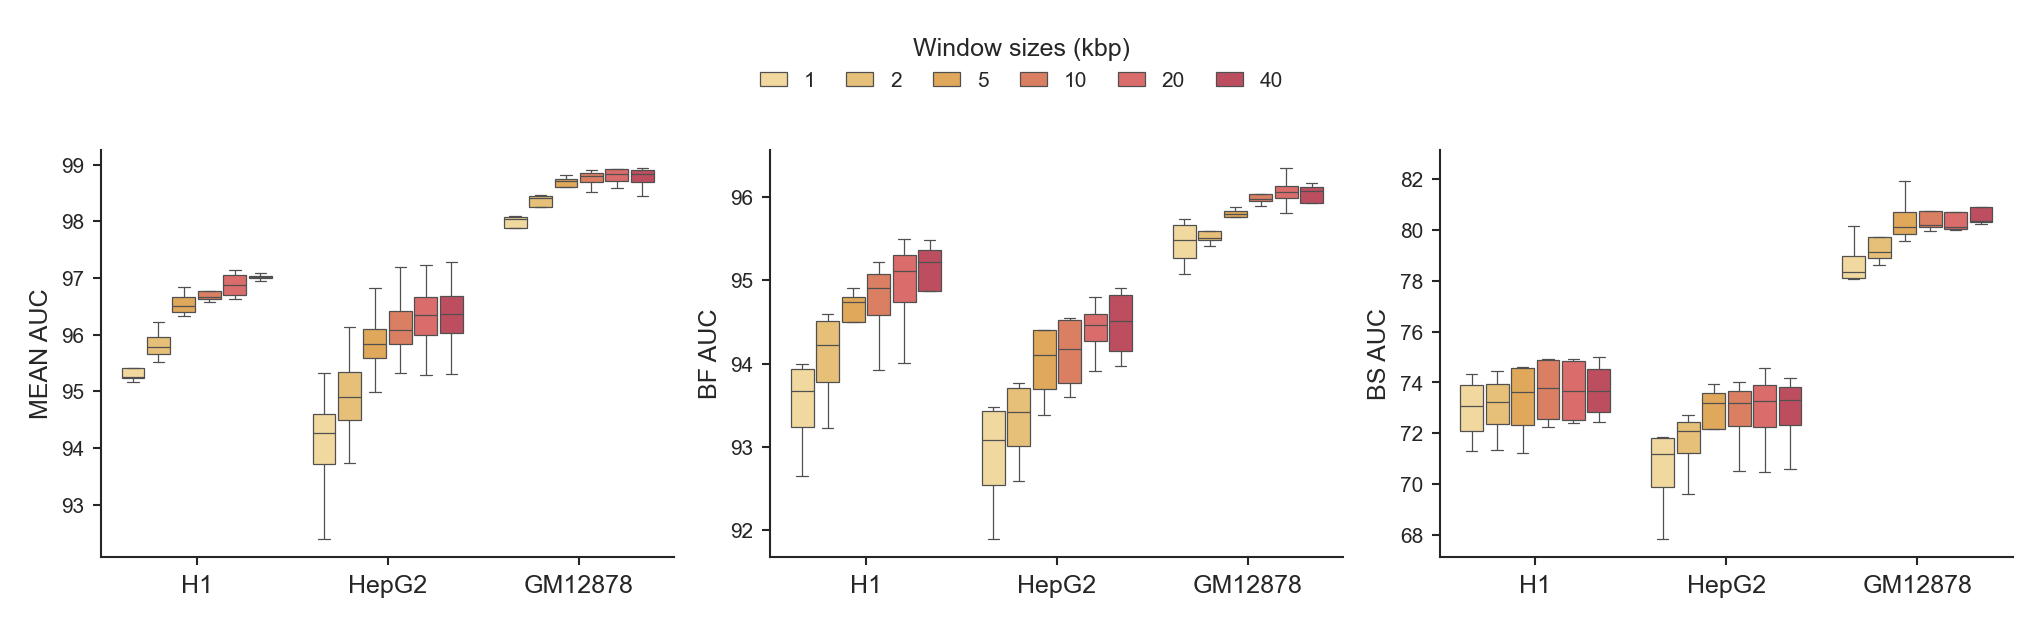

In [8]:
data_mean_distance = pd.read_csv('extra/datasets/results/distance_mean.csv',sep='\t')
fig, ax = plt.subplots(1,3,constrained_layout=True,figsize=(17/2.54, 4/2.54))
# sns.set_palette("muted")
order = pd.Index(["E003","E118","E116"],name='marks')


sns.boxplot(data=data_mean_distance,x='eid',y='mean_auc',hue='distance',fliersize=0,ax=ax[0],linewidth=0.3,order=order,
             gap=0.1,width=0.8,palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],)
ax[0].legend().remove()
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_xlabel('')
ax[0].set_ylabel('MEAN AUC',fontsize=6)

sns.boxplot(data=data,x='eid',y='bf_auc',hue='distance',fliersize=0,ax=ax[1],linewidth=0.3,order=order,
             gap=0.1,width=0.8,palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],
# boxprops=dict( edgecolor=(128/255,128/255,128/255)),  
#             whiskerprops=dict(linewidth=0.5, color=(128/255,128/255,128/255))
            )
handles, labels = ax[1].get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1.01) , title='Distances', fontsize=5,title_fontsize=6,ncol=1)
ax[1].legend().remove()
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_xlabel('')
ax[1].set_ylabel('BF AUC',fontsize=6)

sns.boxplot(data=data,x='eid',y='bs_auc',hue='distance',fliersize=0,ax=ax[2],linewidth=0.3,order=order,
            gap=0.1,width=0.8, palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],
            )


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax[2].legend().remove()
ax[2].tick_params(axis='x', labelsize=6,width=0.5)
ax[2].tick_params(axis='y', labelsize=5,width=0.5)
ax[2].set_xlabel('')
ax[2].set_ylabel('BS AUC',fontsize=6)



ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


fig.legend(handles, labels,title="Window sizes (kbp)", loc='upper center', bbox_to_anchor=(0.5, 1.25), title_fontsize=6,fontsize=5,ncol=6,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
plt.savefig('extra/datasets/figures/Figure2H.eps', format='eps', bbox_inches='tight')
plt.show()